In [4]:
from __future__ import annotations
# ═════════════ IMPORTS & CONFIG ═════════════════════════════════════════
import logging, warnings, joblib
from pathlib import Path
from typing   import Dict, List, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_selection import VarianceThreshold, chi2, f_classif
from sklearn.preprocessing      import OneHotEncoder, MinMaxScaler
from sklearn.metrics            import mean_absolute_error, mean_squared_error, r2_score

import tensorflow as tf
from tensorflow import keras
from keras.layers import LSTM, GRU, Dense, Dropout, Bidirectional
from keras.regularizers import l2

from statsmodels.tsa.seasonal import seasonal_decompose

warnings.filterwarnings("ignore", category=FutureWarning)
logging.basicConfig(level=logging.INFO, format="%(levelname)s | %(message)s")
tf.config.run_functions_eagerly(False)
tf.keras.utils.set_random_seed(42)

# ═════════════ RUTAS & CONSTANTES ═══════════════════════════════════════
BASE_PATH      = Path("./")
DATA_BASE_PATH = BASE_PATH / "data"
FE_BASE_PATH   = DATA_BASE_PATH
RESULTS_PATH   = BASE_PATH / "resultados"
for p in (FE_BASE_PATH, RESULTS_PATH): p.mkdir(parents=True, exist_ok=True)

LOW_VAR, HIGH_CORR = 0.01, 0.95
FILES: Dict[str, str] = {
    "categoria": "consolidado_exportacionestotalcategoria.csv",
    "paises"   : "consolidado_exportaciones_pais.csv",
}

# Arreglo al feature engineering
En nuestro caso nos regresamos a corregir los valores de feature engineering para poder conseguir arreglar unos problemas, simplificarlo y además agregar más valores descriptivos para nuestro problema, tal como lo es un "Moving average" lo cual nos permite ver el promedio de los valores anteriores (dependiendo de la ventana configurada), al igual que otros valores como los Lags, el valor del seno y coseno, etc.

In [5]:
# ═════════════ FUNCIONES AUXILIARES ════════════════════════════════════════════════
def _chi2_anova(df, cat, num):
    y_disc = pd.qcut(df[num], 4, labels=False, duplicates="drop")
    return chi2(pd.get_dummies(df[cat]), y_disc)[1].min(), \
           f_classif(pd.get_dummies(df[cat]), df[num])[1].min()

def _remove_high_corr(df_num, tgt):
    c = df_num.corr().abs(); up = c.where(np.triu(np.ones(c.shape),1).astype(bool))
    return [col for col in up.columns if any(up[col] > HIGH_CORR) and col!=tgt]

def moving_avg(s, win=3): return s.rolling(win,1).mean()
def save_enc(obj, name):  joblib.dump(obj, FE_BASE_PATH/f"{name}.joblib")

# ═════════════ 1. FEATURE ENGINEERING ═══════════════════════════════════
def feature_engineering(df:pd.DataFrame, nombre:str):
    logging.info(f"··· FE: {nombre.upper()} ···")
    df["Fecha"]=pd.to_datetime(df["AñoArchivo"].astype(str)+"-"+df["Mes"].astype(str).str.zfill(2))
    df["Mes"]=df["Fecha"].dt.month

    if nombre!="paises":
        df=df[df["SubCategoria"]!="Total"]; tgt="Valor"; cat_vars=["SubCategoria"]
    else:
        df=(df[df["NombrePais"]=="ESTADOS UNIDOS DE AMERICA"]
              .query("Categoria in ['TEQUILA','TEQUILA 100% DE AGAVE']"))
        tgt="Total_Categoria_Mes"; cat_vars=["Categoria"]

    # lags / MA / estacionalidad
    df["Lag_1"]=df[tgt].shift(1);  df["Lag_12"]=df[tgt].shift(12)
    df["MA_4"]=moving_avg(df[tgt],4); df["MA_12"]=moving_avg(df[tgt],12)
    df["Month_sin"]=np.sin(2*np.pi*df["Mes"]/12); df["Month_cos"]=np.cos(2*np.pi*df["Mes"]/12)

    # OHE
    keep_cat=[]
    for c in cat_vars:
        if c not in df.columns: continue
        p1,p2=_chi2_anova(df,c,tgt)
        if (p1<=0.05) or (p2<=0.05): keep_cat.append(c)
    if keep_cat:
        ohe=OneHotEncoder(drop="first",sparse_output=False,handle_unknown="ignore")
        df=df.join(pd.DataFrame(ohe.fit_transform(df[keep_cat]),
                                columns=ohe.get_feature_names_out(keep_cat),
                                index=df.index))
        df.drop(columns=keep_cat,inplace=True); save_enc(ohe,f"{nombre}_ohe")

    # filtros numéricos
    num=df.select_dtypes("number").fillna(0)
    keep=num.columns[VarianceThreshold(LOW_VAR).fit(num).get_support()]
    df=df[keep.tolist()+[c for c in df.columns if c not in num.columns]]
    df.drop(columns=_remove_high_corr(df.select_dtypes("number"),tgt), inplace=True)
    df.dropna(inplace=True)
    df.to_csv(FE_BASE_PATH/f"{nombre}_features.csv", index=False, encoding="utf-8-sig")

for n,f in FILES.items():
    feature_engineering(pd.read_csv(DATA_BASE_PATH/f), n)

INFO | ··· FE: CATEGORIA ···
INFO | ··· FE: PAISES ···
c:\Users\carlo\anaconda3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:113: RuntimeWarning: divide by zero encountered in divide
  f = msb / msw


# Modelos

## LSTM Bi-GRU multivar


Epoch 16: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 26: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.

Epoch 32: ReduceLROnPlateau reducing learning rate to 6.25000029685907e-05.
Epoch 32: early stopping
Restoring model weights from the end of the best epoch: 20.

► LSTM Bi-GRU (0-1) | MAE 0.3727  RMSE 0.4423  R² 0.060
► LSTM Bi-GRU (L)  | MAE 4 L   RMSE 5 L


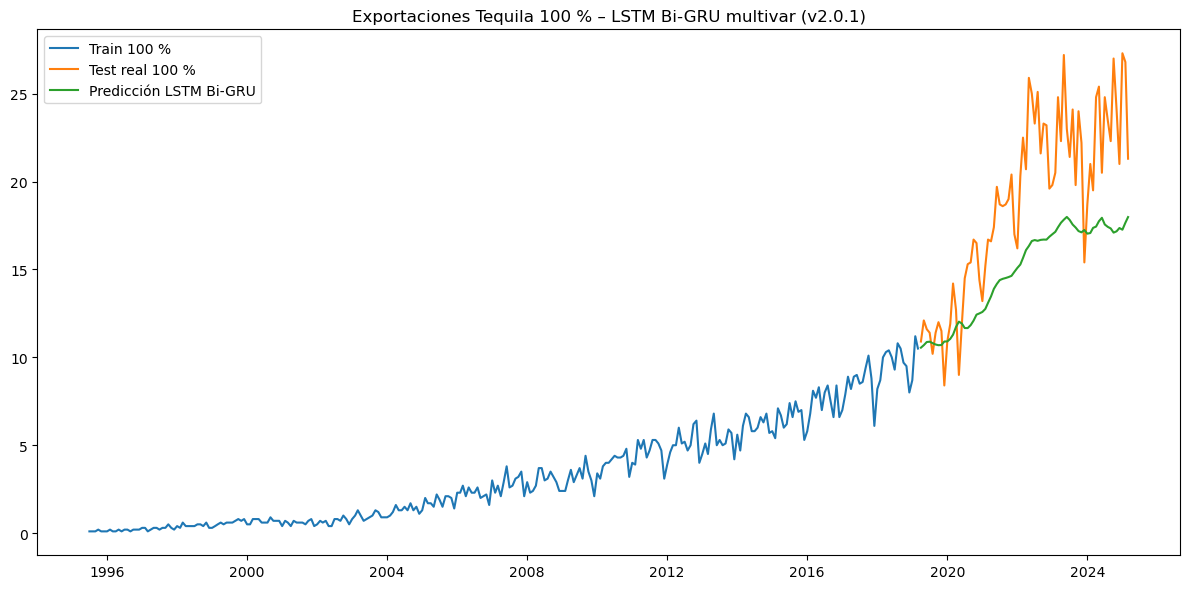

In [6]:
# ═════════════ 2. PREPARACIÓN MULTIVAR ═══════════════════════════════════
df_cat=pd.read_csv(FE_BASE_PATH/"categoria_features.csv",
                   parse_dates=["Fecha"], index_col="Fecha")

base_cols = ["Valor","Lag_1","Lag_12","MA_4","MA_12","Month_sin","Month_cos"]
ohe_cols  = [c for c in df_cat.columns if c.startswith("SubCategoria_")]
feat_cols = [c for c in base_cols if c in df_cat.columns] + ohe_cols

df_100 = df_cat[df_cat["SubCategoria_Tequila 100%"]==1][feat_cols].copy()
CUT=int(len(df_100)*0.8)
train_df, test_df = df_100.iloc[:CUT], df_100.iloc[CUT:]

scaler = MinMaxScaler().fit(train_df)
train_sc = pd.DataFrame(scaler.transform(train_df), index=train_df.index, columns=train_df.columns)
test_sc  = pd.DataFrame(scaler.transform(test_df),  index=test_df.index,  columns=test_df.columns)

# ═════════════ 3. VENTANAS ══════════════════════════════════════════════
WIN=36
def make_windows(df, win=WIN):
    X,y=[],[]
    for i in range(win,len(df)):
        X.append(df.iloc[i-win:i].values)
        y.append(df.iloc[i]["Valor"])
    return np.array(X),np.array(y)

full_sc=pd.concat([train_sc,test_sc])
Xf,yf=make_windows(full_sc.iloc[:CUT+WIN])

split=int(len(Xf)*0.2)
X_val,y_val=Xf[-split:],yf[-split:]
X_train,y_train=Xf[:-split],yf[:-split]


X_test,y_test=make_windows(pd.concat([train_sc.iloc[-WIN:],test_sc]))

n_feat=X_train.shape[2]

# ═════════════ 4. MODELO ════════════════════════════════════════════════
def build_model(win, feat):
    return keras.Sequential([
        keras.Input(shape=(win,feat)),
        Bidirectional(LSTM(64, return_sequences=True, kernel_regularizer=l2(1e-4))),
        GRU(32, kernel_regularizer=l2(1e-4)),
        Dense(32, activation="relu", kernel_regularizer=l2(1e-4)),
        Dropout(0.3),
        Dense(1)
    ])
model=build_model(WIN,n_feat)
model.compile(optimizer=keras.optimizers.Adam(5e-4),
              loss="mae",
              metrics=[keras.metrics.RootMeanSquaredError()])

callbacks=[keras.callbacks.EarlyStopping(monitor="val_loss",patience=12,
                                         restore_best_weights=True,verbose=1),
           keras.callbacks.ReduceLROnPlateau(monitor="val_loss",factor=0.5,
                                             patience=6,min_lr=1e-5,verbose=1)]
model.fit(X_train,y_train,validation_data=(X_val,y_val),
          epochs=300,batch_size=16,callbacks=callbacks,verbose=0)

pred_sc=model.predict(X_test,verbose=0).ravel()

# ═════════════ 5. MÉTRICAS ══════════════════════════════════════════════
mae_sc=mean_absolute_error(y_test,pred_sc)
rmse_sc=mean_squared_error(y_test,pred_sc)**0.5
r2_sc  =r2_score(y_test,pred_sc)
print(f"\n► LSTM Bi-GRU (0-1) | MAE {mae_sc:.4f}  RMSE {rmse_sc:.4f}  R² {r2_sc:.3f}")

# ---- inversa de escala SOLO para la columna Valor ----------------------
idx_val = train_sc.columns.get_loc("Valor")
v_min, v_max = scaler.data_min_[idx_val], scaler.data_max_[idx_val]

y_true_L = y_test*(v_max-v_min) + v_min
y_pred_L = pred_sc*(v_max-v_min) + v_min

mae_L = mean_absolute_error(y_true_L,y_pred_L)
rmse_L= mean_squared_error(y_true_L,y_pred_L)**0.5
print(f"► LSTM Bi-GRU (L)  | MAE {mae_L:,.0f} L   RMSE {rmse_L:,.0f} L")

# ═════════════ 6. GRÁFICA ═══════════════════════════════════════════════
plt.figure(figsize=(12,6))
plt.plot(train_df.index,train_df["Valor"],label="Train 100 %")
plt.plot(test_df.index, test_df["Valor"], label="Test real 100 %")
plt.plot(test_df.index[-len(y_pred_L):], y_pred_L, label="Predicción LSTM Bi-GRU")
plt.title("Exportaciones Tequila 100 % – LSTM Bi-GRU multivar (v2.0.1)")
plt.legend(); plt.tight_layout(); plt.show()


## Funciones auxiliares para LSTM

In [67]:
## Auxiliares LSTM
def sliding_window_lstm(Xdata_df: pd.DataFrame, ydata_df: pd.Series, window_size: int, optional_cols: List[str] = None):
    X_train, y_train = [], []
    dict_col_array = {}

    #Create a sliding window
    for i in range(window_size, len(ydata_df)):
        X_train.append(ydata_df.iloc[i-window_size:i].values) # Agregamos ydata para entrenar y predecir un paso en el futuro
        y_train.append(ydata_df.iloc[i])

    if optional_cols is not None and len(optional_cols) > 0:
        for col in optional_cols:
            aux_arr = []
            for i in range(window_size, len(Xdata_df)):
                aux_arr.append(Xdata_df.iloc[i-window_size:i][col].values)
                
            aux_arr = np.array(aux_arr)
            dict_col_array[col] = aux_arr
            

    X_train, y_train = np.array(X_train), np.array(y_train)

    if optional_cols is not None and len(optional_cols) > 0:
        X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)

        for _, val in dict_col_array.items():
            X_train = np.insert(X_train, -1, val, axis=2)
    else:
        X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1 ))

    return X_train, y_train

def get_seasonal_decompose_data(data_df: pd.DataFrame, target_col: str = "Valor"):
    res_decompose = seasonal_decompose(data_df[target_col], model='additive', extrapolate_trend='freq')

    data_df["seasonal"] = res_decompose.seasonal
    data_df["trend"] = res_decompose.trend
    data_df["resid"] = res_decompose.resid

    return data_df

def plot_decompose_data(data_decomposed_df: pd.DataFrame, observed_col: str = "Valor", v_line: float = 0):
    # res_decompose = seasonal_decompose(full_sc["Valor"], model='additive', extrapolate_trend='freq')

    fig, axs = plt.subplots(nrows=4, ncols=1, figsize=(18, 12), sharex=True)
    data_decomposed_df[observed_col].plot(ax=axs[0])
    axs[0].set_title('Serie original', fontsize=12)
    axs[0].grid()

    data_decomposed_df["trend"].plot(ax=axs[1])
    axs[1].set_title('Tendencia', fontsize=12)
    axs[1].grid()

    data_decomposed_df["seasonal"].plot(ax=axs[2])
    axs[2].set_title('Estacionalidad', fontsize=12)
    axs[2].grid()

    data_decomposed_df["resid"].plot(ax=axs[3])
    axs[3].set_title('Residuos', fontsize=12)
    axs[3].grid()

    if v_line > 0:
        for i in range(len(axs)):
            xmin, xmax = axs[i].get_xlim()
            x_position = xmin + (xmax - xmin) * 0.8
            axs[i].axvline(x=x_position, color='r', linestyle='--')


    fig.suptitle('Descomposición de la serie original vs serie diferenciada', fontsize=14)
    fig.tight_layout()


In [30]:
train_sc
test_sc
full_sc

,Valor,Lag_1,Lag_12,MA_4,Month_sin,Month_cos,SubCategoria_Tequila 100%
Fecha,,,,,,,
1995-07-01,0.000000,0.161905,0.000000,0.098507,0.250000,0.066987,0.0
1995-08-01,0.000000,0.228571,0.000000,0.089552,0.066987,0.250000,0.0
1995-09-01,0.000000,0.342857,0.000000,0.146269,0.000000,0.500000,0.0
1995-10-01,0.009009,0.314286,0.000000,0.176119,0.066987,0.750000,0.0
1995-11-01,0.000000,0.123810,0.000000,0.107463,0.250000,0.933013,0.0
...,...,...,...,...,...,...,...
2024-11-01,2.162162,0.828571,2.364486,1.901493,0.250000,0.933013,0.0
2024-12-01,1.882883,0.523810,1.906542,1.731343,0.500000,1.000000,0.0
2025-01-01,2.450450,0.695238,2.308411,1.785075,0.750000,0.933013,0.0


# Decomposición de datos

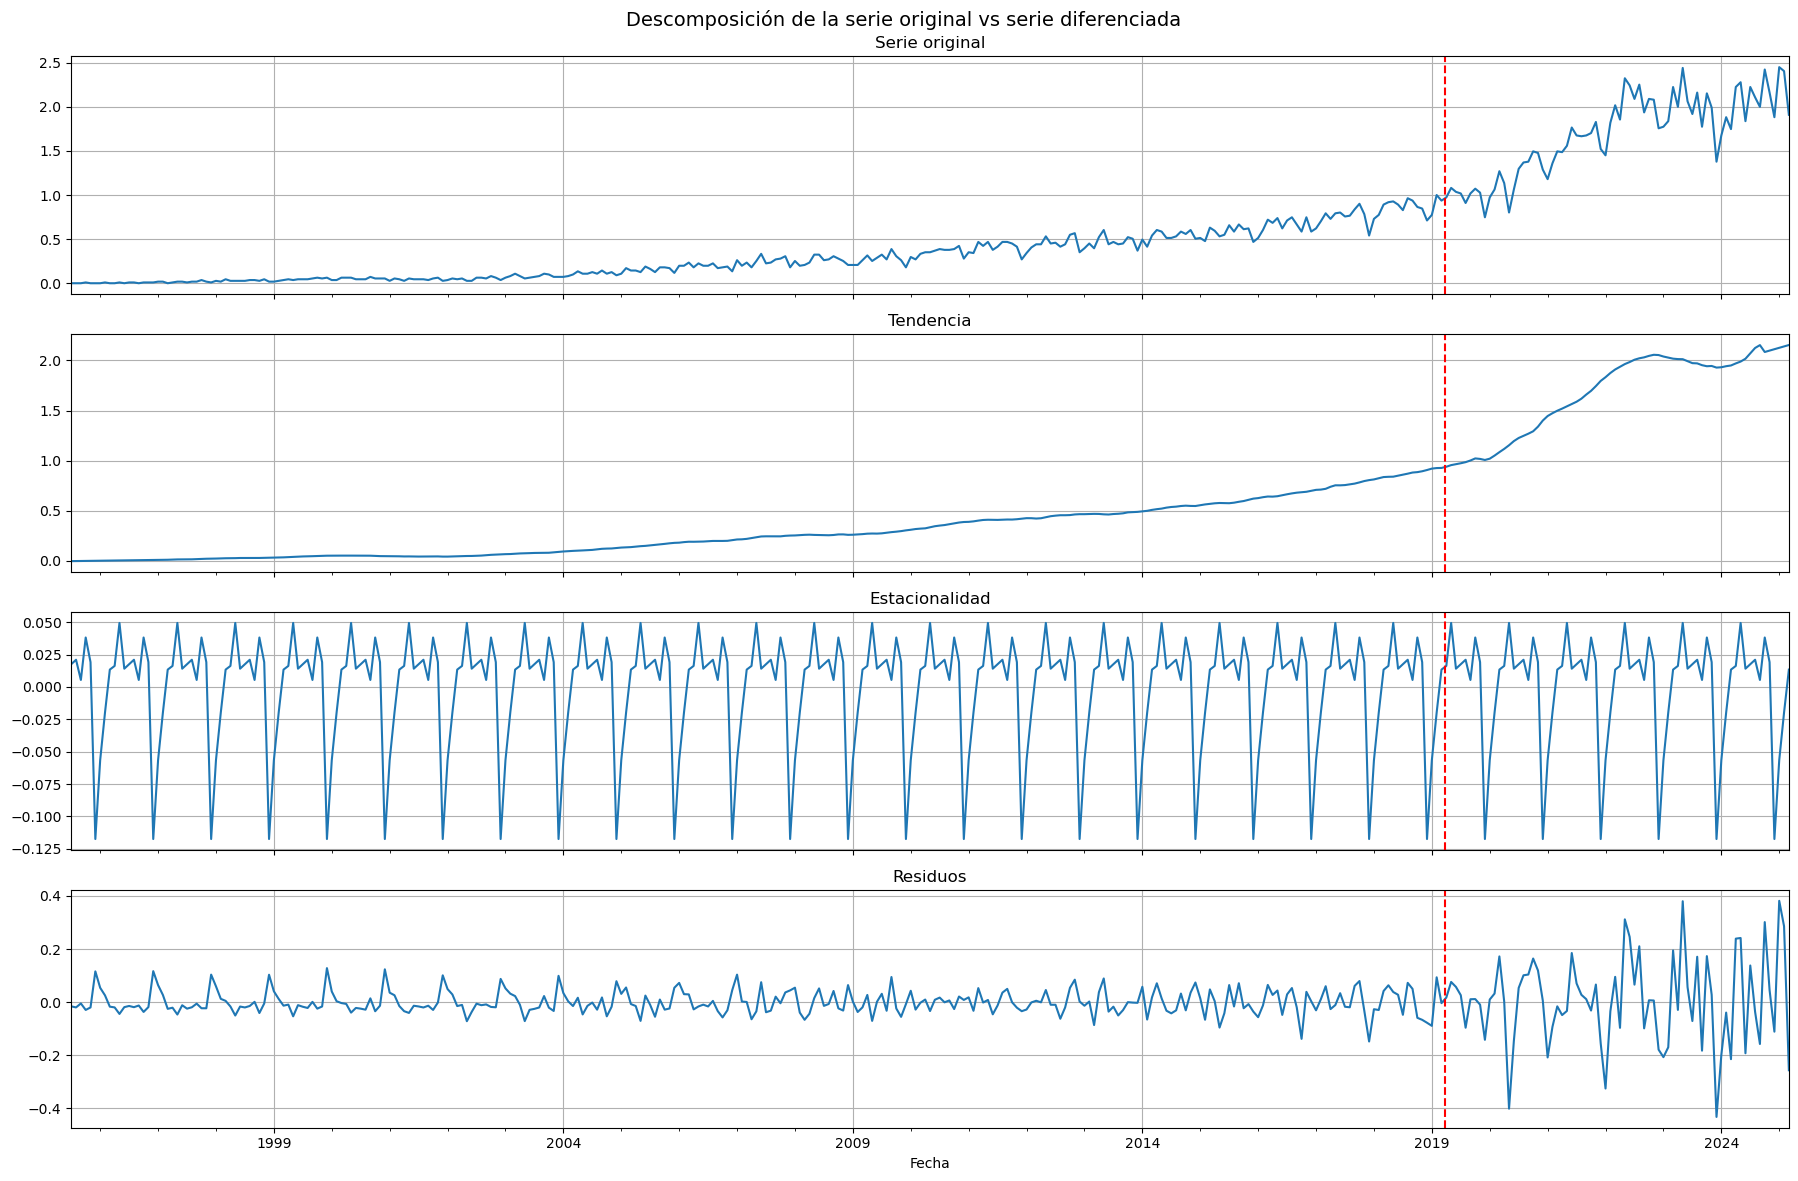

In [31]:
res_decompose = seasonal_decompose(full_sc["Valor"], model='additive', extrapolate_trend='freq')
plot_decompose_data(get_seasonal_decompose_data(full_sc), v_line=0.8)


## Explicación
En la grafica de arriba vemos la decomposicion de los valores, se hizo una linea en el 80% porque esta linea es donde se hace el split de train-test y como podemos observar vemos que la division entre los valores de entrenamiento y pruebas presentan dos comportamientos diferentes, siendo el valor de entrenamiento bastante mas estable que el valor de pruebas el cual se convierte mas volatil en todos sentidos menos en la estacionalidad.

Dando a entender que este presenta un problema para la manera en la cual se implementa la solución debido a que se encuentra un patrón que empieza a evolucionar a medida del tiempo, más adelante veremos como intentamos abordar este problema.

## Uso de los valores de la decomposición de datos para su uso como variables exógenas

In [ ]:
def Xy_split(train_df: pd.DataFrame, test_df: pd.DataFrame, target_col: str = "Valor"):
    X_train = train_df.drop(columns=[target_col])
    y_train = train_df[target_col]

    X_test = test_df.drop(columns=[target_col])
    y_test = test_df[target_col]

    return X_train, y_train, X_test, y_test

    
# Primero hacemos la decomposicion y la hacemos por separado para evitar data leakage
train_dec_df = get_seasonal_decompose_data(train_sc)
test_dec_df = get_seasonal_decompose_data(test_sc)

plot_decompose_data(train_dec_df)
plot_decompose_data(test_dec_df)

# Separamos las variables X e y
X_train, y_train, X_test, y_test = Xy_split(train_dec_df, test_dec_df)

X_train, y_train = sliding_window_lstm(X_train, y_train, window_size=24)

X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))
X_train.shape

### Implementación de LSTM univariado
La primera implementación del LSTM como modelo lo hacemos univariado para usarlo como un baseline del problema.

In [39]:
# Build the Model
model = keras.models.Sequential()

# First Layer
model.add(keras.layers.LSTM(64, return_sequences=True, input_shape=(X_train.shape[1],1)))

# Second Layer
model.add(keras.layers.LSTM(64, return_sequences=False))

# 3rd Layer (Dense)
model.add(keras.layers.Dense(128, activation="relu"))

# 4th Layer (Dropout)
# model.add(keras.layers.Dropout(0.2))

# Final Output Layer
model.add(keras.layers.Dense(1))

model.summary()
model.compile(optimizer="adam",
              loss="mae",
              metrics=[keras.metrics.RootMeanSquaredError()])


training = model.fit(X_train, y_train, epochs=200, batch_size=32)

# X_train = X_train[:len(y_train)]


c:\Users\carlo\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:205: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_7 (LSTM)                   │ (None, 24, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_8 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 58,369 (228.00 KB)

 Trainable params: 58,369 (228.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.2611 - root_mean_squared_error: 0.3550
Epoch 2/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0821 - root_mean_squared_error: 0.0996
Epoch 3/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0429 - root_mean_squared_error: 0.0633
Epoch 4/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0431 - root_mean_squared_error: 0.0594
Epoch 5/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0398 - root_mean_squared_error: 0.0565
Epoch 6/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0443 - root_mean_squared_error: 0.0606
Epoch 7/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0447 - root_mean_squared_error: 0.0614
Epoch 8/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0410 - root_mean_squared_error: 0.0574
Epoch 9/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0383 - root_mean_squared_error: 0.0540
Epoch 10/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0418 - root_mean_squared_error: 0.0581
Epoch 11/200
9/9 ━━

72

72

(72, 24, 1)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 

► LSTM Bi-GRU (0-1) | MAE 0.5320  RMSE 0.6312  R² -0.914
► LSTM Bi-GRU (L)  | MAE 6 L   RMSE 7 L


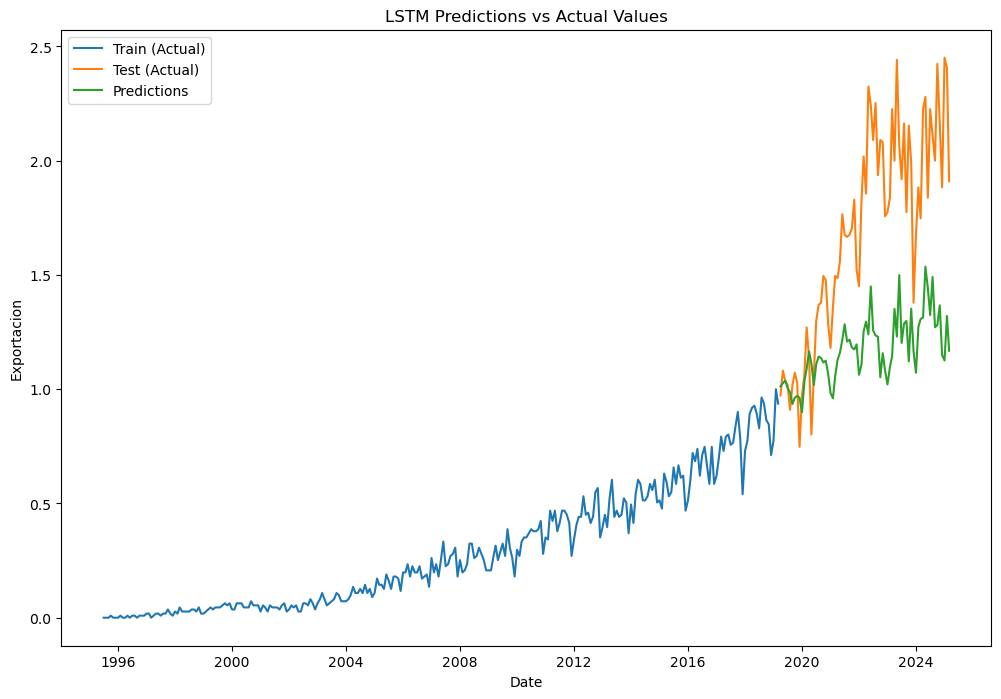

In [42]:
# Prep the test data
last_24_rows = y_train[-24:]
y_test_ext = pd.Series(np.concatenate((last_24_rows, y_test)))

X_test_2, y_test_2 = sliding_window_lstm(X_test, y_test_ext, window_size=24)

# Make a Prediction
ltsm_predictions = model.predict(X_test_2)

# ═════════════ 5. MÉTRICAS ══════════════════════════════════════════════
mae_sc=mean_absolute_error(y_test, ltsm_predictions)
rmse_sc=mean_squared_error(y_test, ltsm_predictions)**0.5
r2_sc  =r2_score(y_test,ltsm_predictions)
print(f"\n► LSTM 1 Dimensional | MAE {mae_sc:.4f}  RMSE {rmse_sc:.4f}  R² {r2_sc:.3f}")

# ---- inversa de escala SOLO para la columna Valor ----------------------
idx_val = train_sc.columns.get_loc("Valor")
v_min, v_max = scaler.data_min_[idx_val], scaler.data_max_[idx_val]

display

y_true_L = y_test*(v_max-v_min) + v_min
y_pred_L = ltsm_predictions*(v_max-v_min) + v_min

mae_L = mean_absolute_error(y_true_L,y_pred_L)
rmse_L= mean_squared_error(y_true_L,y_pred_L)**0.5
print(f"► LSTM 1 Dimensional  | MAE {mae_L:,.0f} L   RMSE {rmse_L:,.0f} L")

# ═════════════ 6. GRÁFICA ═══════════════════════════════════════════════

# Plotting data
train_ltsm = train_dec_df.copy()
test_ltsm = test_dec_df.copy()

test_ltsm['Predictions'] = ltsm_predictions

plt.figure(figsize=(12,8))
plt.plot(train_ltsm.index, train_ltsm['Valor'], label="Train (Actual)")
plt.plot(test_ltsm.index, test_ltsm['Valor'], label="Test (Actual)")
plt.plot(test_ltsm.index, test_ltsm['Predictions'], label="Predictions")
plt.title("LSTM Predictions vs Actual Values")
plt.xlabel("Date")
plt.ylabel("Exportacion")
plt.legend()
plt.show()

### LSTM con variables exógenas, seasonality y trend

In [43]:
X_train, y_train, X_test, y_test = Xy_split(train_dec_df, test_dec_df)

X_train_sw, y_train_sw = sliding_window_lstm(X_train, y_train, window_size=24, optional_cols=["seasonal", "trend"])

# Build the Model
model_2exog = keras.models.Sequential()
# First Layer
model_2exog.add(keras.layers.LSTM(64, return_sequences=True, input_shape=(X_train_sw.shape[1], X_train_sw.shape[2])))
# Second Layer
model_2exog.add(keras.layers.LSTM(64, return_sequences=False))
# 3rd Layer (Dense)
model_2exog.add(keras.layers.Dense(128, activation="relu"))
# 4th Layer (Dropout)
# model_2exog.add(keras.layers.Dropout(0.2))
# Final Output Layer
model_2exog.add(keras.layers.Dense(1))
model_2exog.summary()
model_2exog.compile(optimizer="adam",
              loss="mae",
              metrics=[keras.metrics.RootMeanSquaredError()])


training = model_2exog.fit(X_train_sw, y_train_sw, epochs=200, batch_size=32)

# X_train = X_train[:len(y_train)]


c:\Users\carlo\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:205: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_9 (LSTM)                   │ (None, 24, 64)         │        17,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_10 (LSTM)                  │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 58,881 (230.00 KB)

 Trainable params: 58,881 (230.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.2072 - root_mean_squared_error: 0.2888
Epoch 2/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0686 - root_mean_squared_error: 0.0992
Epoch 3/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0428 - root_mean_squared_error: 0.0616
Epoch 4/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0382 - root_mean_squared_error: 0.0535
Epoch 5/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0381 - root_mean_squared_error: 0.0559
Epoch 6/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0371 - root_mean_squared_error: 0.0526
Epoch 7/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0371 - root_mean_squared_error: 0.0532
Epoch 8/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0375 - root_mean_squared_error: 0.0540
Epoch 9/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0367 - root_mean_squared_error: 0.0528
Epoch 10/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0364 - root_mean_squared_error: 0.0520
Epoch 11/200
9/9 ━━

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step

► LSTM 1 Dimensional | MAE 0.4597  RMSE 0.5969  R² -0.712
► LSTM 1 Dimensional  | MAE 5 L   RMSE 7 L


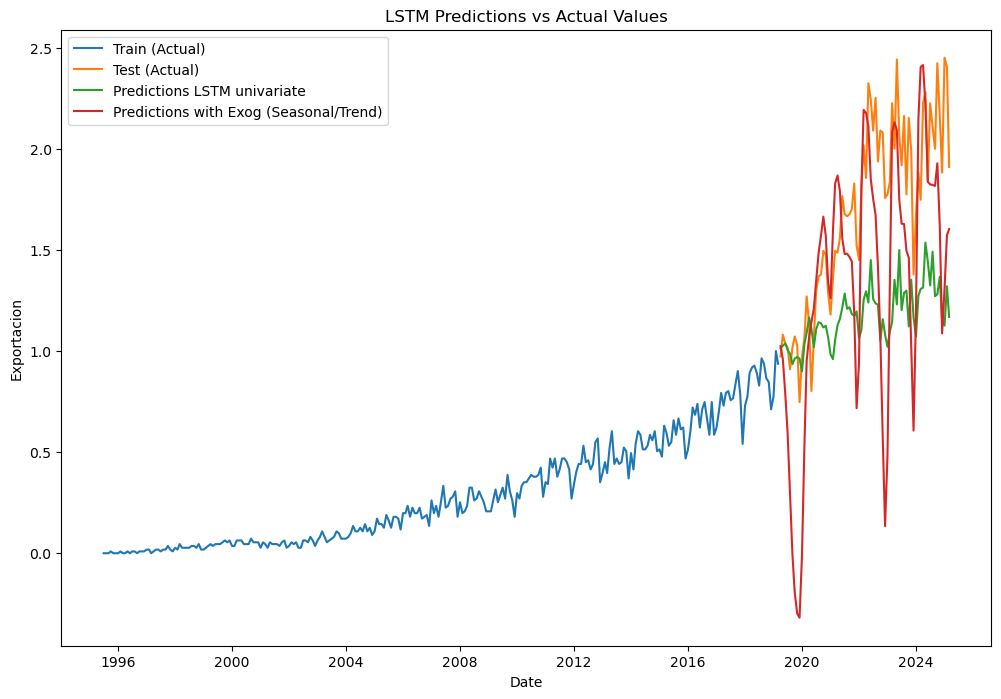

In [46]:
# Prep the test data
last_24_rows = y_train[-24:]
y_test_ext = pd.Series(np.concatenate((last_24_rows, y_test)))
X_test_ext = pd.concat([X_train.tail(24), X_test])

X_test_2, y_test_2 = sliding_window_lstm(X_test_ext, y_test_ext, window_size=24, optional_cols=["seasonal", "trend"])

# Make a Prediction
ltsm_predictions_exog = model_2exog.predict(X_test_2)

# ═════════════ 5. MÉTRICAS ══════════════════════════════════════════════
mae_sc=mean_absolute_error(y_test, ltsm_predictions_exog)
rmse_sc=mean_squared_error(y_test, ltsm_predictions_exog)**0.5
r2_sc  =r2_score(y_test,ltsm_predictions_exog)
print(f"\n► LSTM 1 Dimensional | MAE {mae_sc:.4f}  RMSE {rmse_sc:.4f}  R² {r2_sc:.3f}")

# ---- inversa de escala SOLO para la columna Valor ----------------------
idx_val = train_sc.columns.get_loc("Valor")
v_min, v_max = scaler.data_min_[idx_val], scaler.data_max_[idx_val]


y_true_L = y_test*(v_max-v_min) + v_min
y_pred_L = ltsm_predictions_exog*(v_max-v_min) + v_min

mae_L = mean_absolute_error(y_true_L,y_pred_L)
rmse_L= mean_squared_error(y_true_L,y_pred_L)**0.5
print(f"► LSTM 1 Dimensional  | MAE {mae_L:,.0f} L   RMSE {rmse_L:,.0f} L")

# ═════════════ 6. GRÁFICA ═══════════════════════════════════════════════

# Plotting data
train_ltsm = train_dec_df.copy()
test_ltsm = test_dec_df.copy()

test_ltsm['Predictions'] = ltsm_predictions
test_ltsm['Predictions_exog'] = ltsm_predictions_exog

plt.figure(figsize=(12,8))
plt.plot(train_ltsm.index, train_ltsm['Valor'], label="Train (Actual)")
plt.plot(test_ltsm.index, test_ltsm['Valor'], label="Test (Actual)")
plt.plot(test_ltsm.index, test_ltsm['Predictions'], label="Predictions LSTM univariate")
plt.plot(test_ltsm.index, test_ltsm['Predictions_exog'], label="Predictions with Exog (Seasonal/Trend)")
plt.title("LSTM Predictions vs Actual Values")
plt.xlabel("Date")
plt.ylabel("Exportacion")
plt.legend()
plt.show()

## Explicación
Notamos como las variables exogenas han ayudado a acercarse en ciertos puntos a los valores actuales, sin embargo, encontramos tambien el problema de unos picos muy bajos, por otro lado, el LSTM univariado presenta mejores resultados en nuestra opinión debido a que este solo requiere una mayor corrección a la tendencia en general, pendiente de seguir experimentando.

# Walk forward validation

Esta tecnica permite la prediccion de valores mediante una ventana corrediza la cual ayuda a casos donde se tienen que predecir una serie de datos temporales los cuales tienen patrones nuevos, lo cual podemos ver en este caso, es por esto que se optó por realizar un boceto de su implementacion usando LSTM, sin embargo, mirando atrás tal vez esta implementacion en un LSTM no sea la mas adecuada ya que vence la arquitectura de esta, a pesar de esto, podemos aprovechar essta misma implementación para experimentar con otros modelos mas ligeros como ARMAX o ARIMAX y Exponential Smoothing, no tanto un LSTM.

In [78]:
def lstm_model(input_shape):
    # Build the Model
    model = keras.models.Sequential()

    model.add(keras.layers.LSTM(64, return_sequences=True, input_shape=input_shape))
    model.add(keras.layers.LSTM(64, return_sequences=False))
    model.add(keras.layers.Dense(128, activation="relu"))
    model.add(keras.layers.Dense(1))

    model.summary()
    model.compile(optimizer="adam",
                loss="mae",
                metrics=[keras.metrics.RootMeanSquaredError()])
    
    return model


def walk_forward_validation(data_df: pd.DataFrame, target_col:str = "Valor", training_window: int = 36, test_window: int = 1):
    """
    Walk-forward validation for time series forecasting.
    """
    actuals = []
    predictions = []
    metrics = []
    sliding_window_size = 24

    for i in range(0,
                   len(data_df) - training_window - test_window,
                    test_window):
        
        # Split into train-test sets
        train_data = data_df[i:i + training_window]
        test_data = data_df[i + training_window : i + training_window + test_window]

        # Decompose
        train_dec_df = get_seasonal_decompose_data(train_data, target_col)

        # Divide into X and y
        X_train, y_train, X_test, y_test = Xy_split(train_dec_df, test_data, target_col)

        # Create sliding window
        X_train_sw, y_train_sw = sliding_window_lstm(X_train, y_train, window_size=sliding_window_size, optional_cols=["seasonal", "trend"])

        # Create the model and fit
        print(f"Shape of prediction")
        print((X_train_sw.shape[1], X_train_sw.shape[2]))
        model = lstm_model((X_train_sw.shape[1], X_train_sw.shape[2]))
        model.fit(X_train_sw, y_train_sw, epochs=100, batch_size=32, verbose=0)

        # Prep the test data
        last_window_rows = y_train[-sliding_window_size:]
        y_test_ext = pd.Series(np.concatenate((last_window_rows, y_test)))
        X_test_ext = pd.concat([X_train.tail(sliding_window_size), X_test])

        X_test_2, _ = sliding_window_lstm(X_test_ext, y_test_ext, window_size=sliding_window_size, optional_cols=["seasonal", "trend"])

        # Make a Prediction
        ltsm_predictions = model.predict(X_test_2)
        
        # Calculate metrics
        predictions.extend(ltsm_predictions.ravel())
        actuals.extend(y_test.values)

        mae_sc=mean_absolute_error(y_test, ltsm_predictions)
        rmse_sc=mean_squared_error(y_test, ltsm_predictions)**0.5
        r2_sc  =r2_score(y_test,ltsm_predictions)
        metrics.append({
            "MAE": mae_sc,
            "RMSE": rmse_sc,
            "R2": r2_sc
        })

    return predictions, actuals, metrics

In [79]:
predictions, actuals, metrics = walk_forward_validation(data_df=full_sc, target_col="Valor", training_window=36, test_window=1)

Shape of prediction
(24, 3)


C:\Users\carlo\AppData\Local\Temp\ipykernel_37620\212477041.py:36: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_df["seasonal"] = res_decompose.seasonal
C:\Users\carlo\AppData\Local\Temp\ipykernel_37620\212477041.py:37: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_df["trend"] = res_decompose.trend
C:\Users\carlo\AppData\Local\Temp\ipykernel_37620\212477041.py:38: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = v

Model: "sequential_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_27 (LSTM)                  │ (None, 24, 64)         │        17,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_28 (LSTM)                  │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 58,881 (230.00 KB)

...

 Total params: 58,881 (230.00 KB)

 Trainable params: 58,881 (230.00 KB)

 Non-trainable params: 0 (0.00 B)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 258ms/step


c:\Users\carlo\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:1187: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)


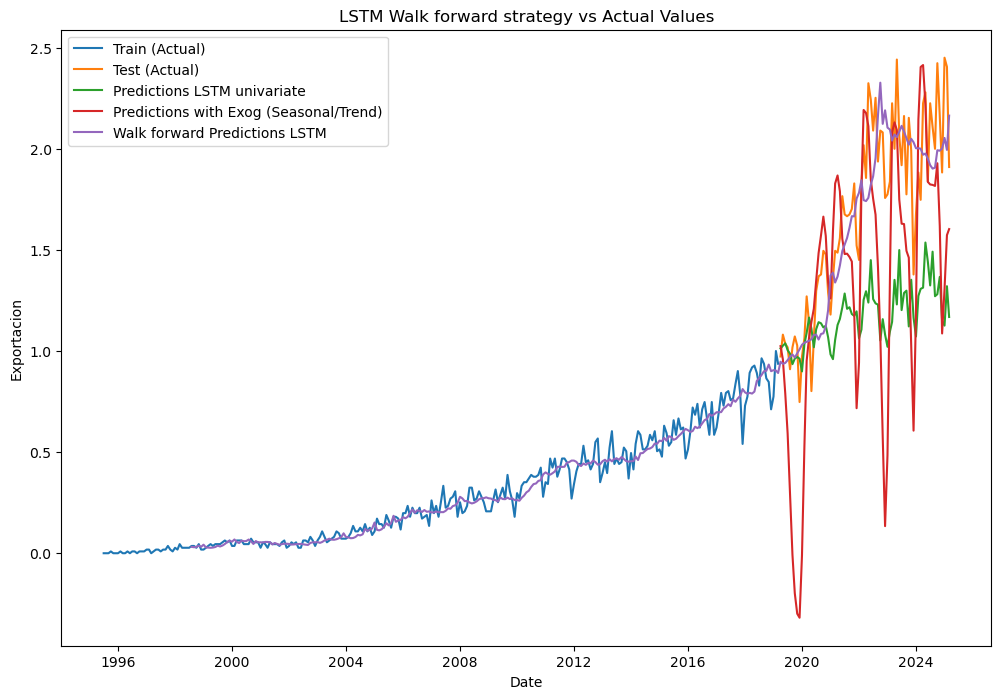

In [83]:
wf_df = full_sc[37:].copy()

wf_df["Walk_forward_Predictions"] = predictions

plt.figure(figsize=(12,8))
plt.plot(train_ltsm.index, train_ltsm['Valor'], label="Train (Actual)")
plt.plot(test_ltsm.index, test_ltsm['Valor'], label="Test (Actual)")
plt.plot(test_ltsm.index, test_ltsm['Predictions'], label="Predictions LSTM univariate")
plt.plot(test_ltsm.index, test_ltsm['Predictions_exog'], label="Predictions with Exog (Seasonal/Trend)")
plt.plot(wf_df.index, wf_df["Walk_forward_Predictions"], label="Walk forward Predictions LSTM")
plt.title("LSTM Walk forward strategy vs Actual Values")
plt.xlabel("Date")
plt.ylabel("Exportacion")
plt.legend()
plt.show()

# Conclusiones
Con esta última ejecución para la predicción de los datos, vemos que tenemos resultados muy variados al respecto de las implementaciones de LSTM, vemos que el mejor resultado fue agregando las variables conseguidas de los últimos 24 registros del valor, la tendencia y la temporalidad proveyendo a la red neuronal mas informacion para describir el comportamiento de los datos y permitiendole aprender mas de ellos.

En este caso, vemos que la estrategia del walking forward si mejora bastante la consistencia de las predicciones pero tenemos un problema que esta implementacion consiste de muchos pequeños pasos para predecir el siguiente valor inmediato ya que asi fue diseñado el LSTM y sirve para mostrar el desempeño a lo largo del tiempo del modelo, sin embargo esta implementación seria algo parecida para empezar a predecir los valores futuros.